In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

In [4]:
df = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data_df.csv"), index_col=0)
df["type"] = "top_track"
df

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Believe,Micheal Woods,0.832951,1.041581,1.029700,0.873513,top_track
1,Executive,Micheal Woods,0.779545,0.793655,0.987299,0.970585,top_track
2,This fall,Micheal Woods,0.900645,1.194748,0.928675,0.988203,top_track
3,Care hair,Micheal Woods,0.974839,0.933725,0.980782,0.923037,top_track
4,Computer blood,Micheal Woods,1.091138,1.163467,0.998281,0.937892,top_track
...,...,...,...,...,...,...,...
74995,Democrat past,Dave Pitts,0.948012,0.959504,0.902671,0.851102,top_track
74996,Defense,Dave Pitts,0.801451,1.048954,0.972620,1.043628,top_track
74997,Drug she head,Dave Pitts,1.085254,1.189520,1.030366,1.159210,top_track
74998,Behind major,Dave Pitts,0.951674,1.081677,1.107865,1.004385,top_track


## Setup the dataset

In [5]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["affinity"] *= 100
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_14170/974139183.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Believe,Micheal Woods,0.832951,1.041581,1.029700,87.351252,top_track
1,Executive,Micheal Woods,0.779545,0.793655,0.987299,97.058483,top_track
2,This fall,Micheal Woods,0.900645,1.194748,0.928675,98.820298,top_track
3,Care hair,Micheal Woods,0.974839,0.933725,0.980782,92.303741,top_track
4,Computer blood,Micheal Woods,1.091138,1.163467,0.998281,93.789151,top_track
...,...,...,...,...,...,...,...
74995,Democrat past,Dave Pitts,0.948012,0.959504,0.902671,85.110231,top_track
74996,Defense,Dave Pitts,0.801451,1.048954,0.972620,104.362802,top_track
74997,Drug she head,Dave Pitts,1.085254,1.189520,1.030366,115.921029,top_track
74998,Behind major,Dave Pitts,0.951674,1.081677,1.107865,100.438461,top_track


In [6]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 2)
df_matrix_mf_filtered

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Believe,Micheal Woods,0.832951,1.041581,1.029700,87.351252,top_track
1,Executive,Micheal Woods,0.779545,0.793655,0.987299,97.058483,top_track
6,Beautiful,Micheal Woods,1.025424,1.075975,1.007222,103.434927,top_track
8,Easy economy,Micheal Woods,1.113428,1.042027,0.935638,91.880565,top_track
10,Community,Micheal Woods,0.951959,1.102640,0.904035,96.586387,top_track
...,...,...,...,...,...,...,...
74984,Capital,Dave Pitts,0.981935,1.016363,1.038267,106.967027,top_track
74985,Myself tree,Dave Pitts,0.971760,0.901803,1.002930,95.219399,top_track
74990,Either,Dave Pitts,1.086794,0.982535,0.960099,109.950653,top_track
74996,Defense,Dave Pitts,0.801451,1.048954,0.972620,104.362802,top_track


In [7]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 498 users, 30530 items and 59434 interactions, so the sparsity is 0.39%.


In [8]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_14170/3495685520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_14170/3495685520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()


In [9]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
Karen Obrien        285
Lisa Miller         159
David Erickson      150
Ashley Brock        150
Patricia Costa      150
                   ... 
Krystal Stanley      26
Tara Davenport       25
Christina Hudson     24
Michael Wilson       23
Nancy Baker          21
Name: count, Length: 498, dtype: int64

,count,old_index
username,,
Heather Pope,28,Heather Pope
Paula Sellers,148,Paula Sellers
Dylan Bryant,135,Dylan Bryant
Alexa Tran,143,Alexa Tran
Casey Wolfe,135,Casey Wolfe
...,...,...
Brandy Manning,147,Brandy Manning
Timothy Gonzales,132,Timothy Gonzales
Betty Edwards,127,Betty Edwards


In [10]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.2, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
Heather Pope,28,Heather Pope
Paula Sellers,148,Paula Sellers
Dylan Bryant,135,Dylan Bryant
Alexa Tran,143,Alexa Tran
Casey Wolfe,135,Casey Wolfe
...,...,...
Brandy Manning,147,Brandy Manning
Timothy Gonzales,132,Timothy Gonzales
Betty Edwards,127,Betty Edwards


Train data:


,count,old_index
username,,
Heather Pope,28,Heather Pope
Paula Sellers,148,Paula Sellers
Dylan Bryant,135,Dylan Bryant
Alexa Tran,143,Alexa Tran
Casey Wolfe,135,Casey Wolfe
...,...,...
Todd Stewart,146,Todd Stewart
Bobby Huffman,132,Bobby Huffman
Cody Hansen,60,Cody Hansen


Validation data:


,count,old_index
username,,
Samantha Holt,129,Samantha Holt
Kimberly Cox,146,Kimberly Cox
Becky Hall,126,Becky Hall
Aaron Green,149,Aaron Green
James Benson,29,James Benson
...,...,...
Amy Anderson,48,Amy Anderson
Daniel Russell,49,Daniel Russell
Regina Duran,128,Regina Duran


Test data:


,count,old_index
username,,
Jim Anderson,136,Jim Anderson
Joshua Ortega,131,Joshua Ortega
Amanda Bailey,38,Amanda Bailey
Valerie Lopez,134,Valerie Lopez
Matthew Johnston,28,Matthew Johnston
...,...,...
Brandy Manning,147,Brandy Manning
Timothy Gonzales,132,Timothy Gonzales
Betty Edwards,127,Betty Edwards


Train data:


/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_14170/3878578060.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["username"] = train_df["username"].cat.remove_unused_categories()


,id,username,danceability,duration_ms,instrumentalness,affinity,type
150,Moment ball,Lynn Butler,1.210069,1.048728,1.081792,92.349883,top_track
151,Keep type age,Lynn Butler,1.033764,0.967695,0.907196,89.662595,top_track
152,Indicate Mr,Lynn Butler,1.110968,0.964470,1.040711,94.041864,top_track
153,Notice product,Lynn Butler,0.977307,1.104749,0.987192,112.494807,top_track
154,School others,Lynn Butler,1.071715,0.985325,1.109987,98.375195,top_track
...,...,...,...,...,...,...,...
74984,Capital,Dave Pitts,0.981935,1.016363,1.038267,106.967027,top_track
74985,Myself tree,Dave Pitts,0.971760,0.901803,1.002930,95.219399,top_track
74990,Either,Dave Pitts,1.086794,0.982535,0.960099,109.950653,top_track
74996,Defense,Dave Pitts,0.801451,1.048954,0.972620,104.362802,top_track


Validation train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
48600,Short world,Aaron Green,1.066364,1.046811,1.000887,100.431414,top_track
48602,Indeed feeling,Aaron Green,1.062203,1.117795,1.065848,110.885389,top_track
48603,Worry none,Aaron Green,0.930755,1.012902,0.961530,121.509947,top_track
48606,Cultural treat,Aaron Green,0.890448,0.958820,1.003365,107.318971,top_track
48607,School large,Aaron Green,0.768261,0.877546,1.136141,100.920927,top_track
...,...,...,...,...,...,...,...
37329,Young green,Wendy Bryan,1.113412,0.937270,0.994361,96.493346,top_track
37337,Middle feel,Wendy Bryan,1.090841,0.920383,0.980546,97.364778,top_track
37338,Charge lawyer,Wendy Bryan,1.019346,0.994357,1.090165,94.967701,top_track
37340,Wrong,Wendy Bryan,1.210741,0.988578,1.050433,97.944410,top_track


...

,id,username,danceability,duration_ms,instrumentalness,affinity,type
48601,Must attorney,Aaron Green,0.943599,1.121408,0.983492,99.671690,top_track
48604,Financial,Aaron Green,0.778687,0.977379,0.853644,115.729284,top_track
48605,Turn little,Aaron Green,0.931619,1.050225,1.045330,81.740399,top_track
48608,Save grow,Aaron Green,0.828983,1.212610,1.030365,111.887247,top_track
48609,Piece who,Aaron Green,0.960066,1.027693,0.962981,98.649998,top_track
...,...,...,...,...,...,...,...
37317,Theory,Wendy Bryan,1.209732,0.802709,0.903272,109.149996,top_track
37328,Skill special,Wendy Bryan,0.892108,1.070935,0.867840,87.248713,top_track
37335,Trip,Wendy Bryan,0.876353,0.919158,1.333140,104.205421,top_track
37339,Maybe appear,Wendy Bryan,0.895229,1.174799,0.861486,99.443207,top_track


Test train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
55050,Accept idea,Adam Sellers MD,1.130341,1.083119,0.827658,88.882895,top_track
55051,Mrs fine,Adam Sellers MD,1.079389,1.163368,0.928097,88.963445,top_track
55053,Exist show,Adam Sellers MD,1.019616,0.872804,0.978482,104.324179,top_track
55054,American,Adam Sellers MD,0.836437,1.165823,1.066039,122.461265,top_track
55056,Fear Democrat,Adam Sellers MD,1.051598,0.958312,0.953825,95.742038,top_track
...,...,...,...,...,...,...,...
69742,Pattern car,Zachary Williams,1.044739,0.884565,0.915919,114.040833,top_track
69744,Daughter fact,Zachary Williams,0.888590,0.890588,1.003539,122.756822,top_track
69745,Rate last,Zachary Williams,0.854121,0.875448,1.154890,111.455076,top_track
69746,Modern rock,Zachary Williams,1.119361,1.077939,1.087268,118.395880,top_track


Test test data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
55052,Since alone,Adam Sellers MD,0.896610,0.878817,0.935739,97.630723,top_track
55055,Child read,Adam Sellers MD,0.982285,0.881948,1.200795,101.230658,top_track
55057,Military worry,Adam Sellers MD,1.178750,0.997560,1.217292,92.539726,top_track
55058,Money day,Adam Sellers MD,1.058368,0.980326,0.844232,108.950796,top_track
55060,Think about,Adam Sellers MD,1.019672,1.027526,1.030263,102.753328,top_track
...,...,...,...,...,...,...,...
69732,Teach age thus,Zachary Williams,0.943218,0.942886,0.954219,107.589960,top_track
69735,Recognize,Zachary Williams,1.030024,1.121198,0.913804,104.328220,top_track
69741,Wrong,Zachary Williams,1.001529,1.026872,0.903382,95.097329,top_track
69743,There world,Zachary Williams,1.056225,0.926627,0.991749,108.119350,top_track


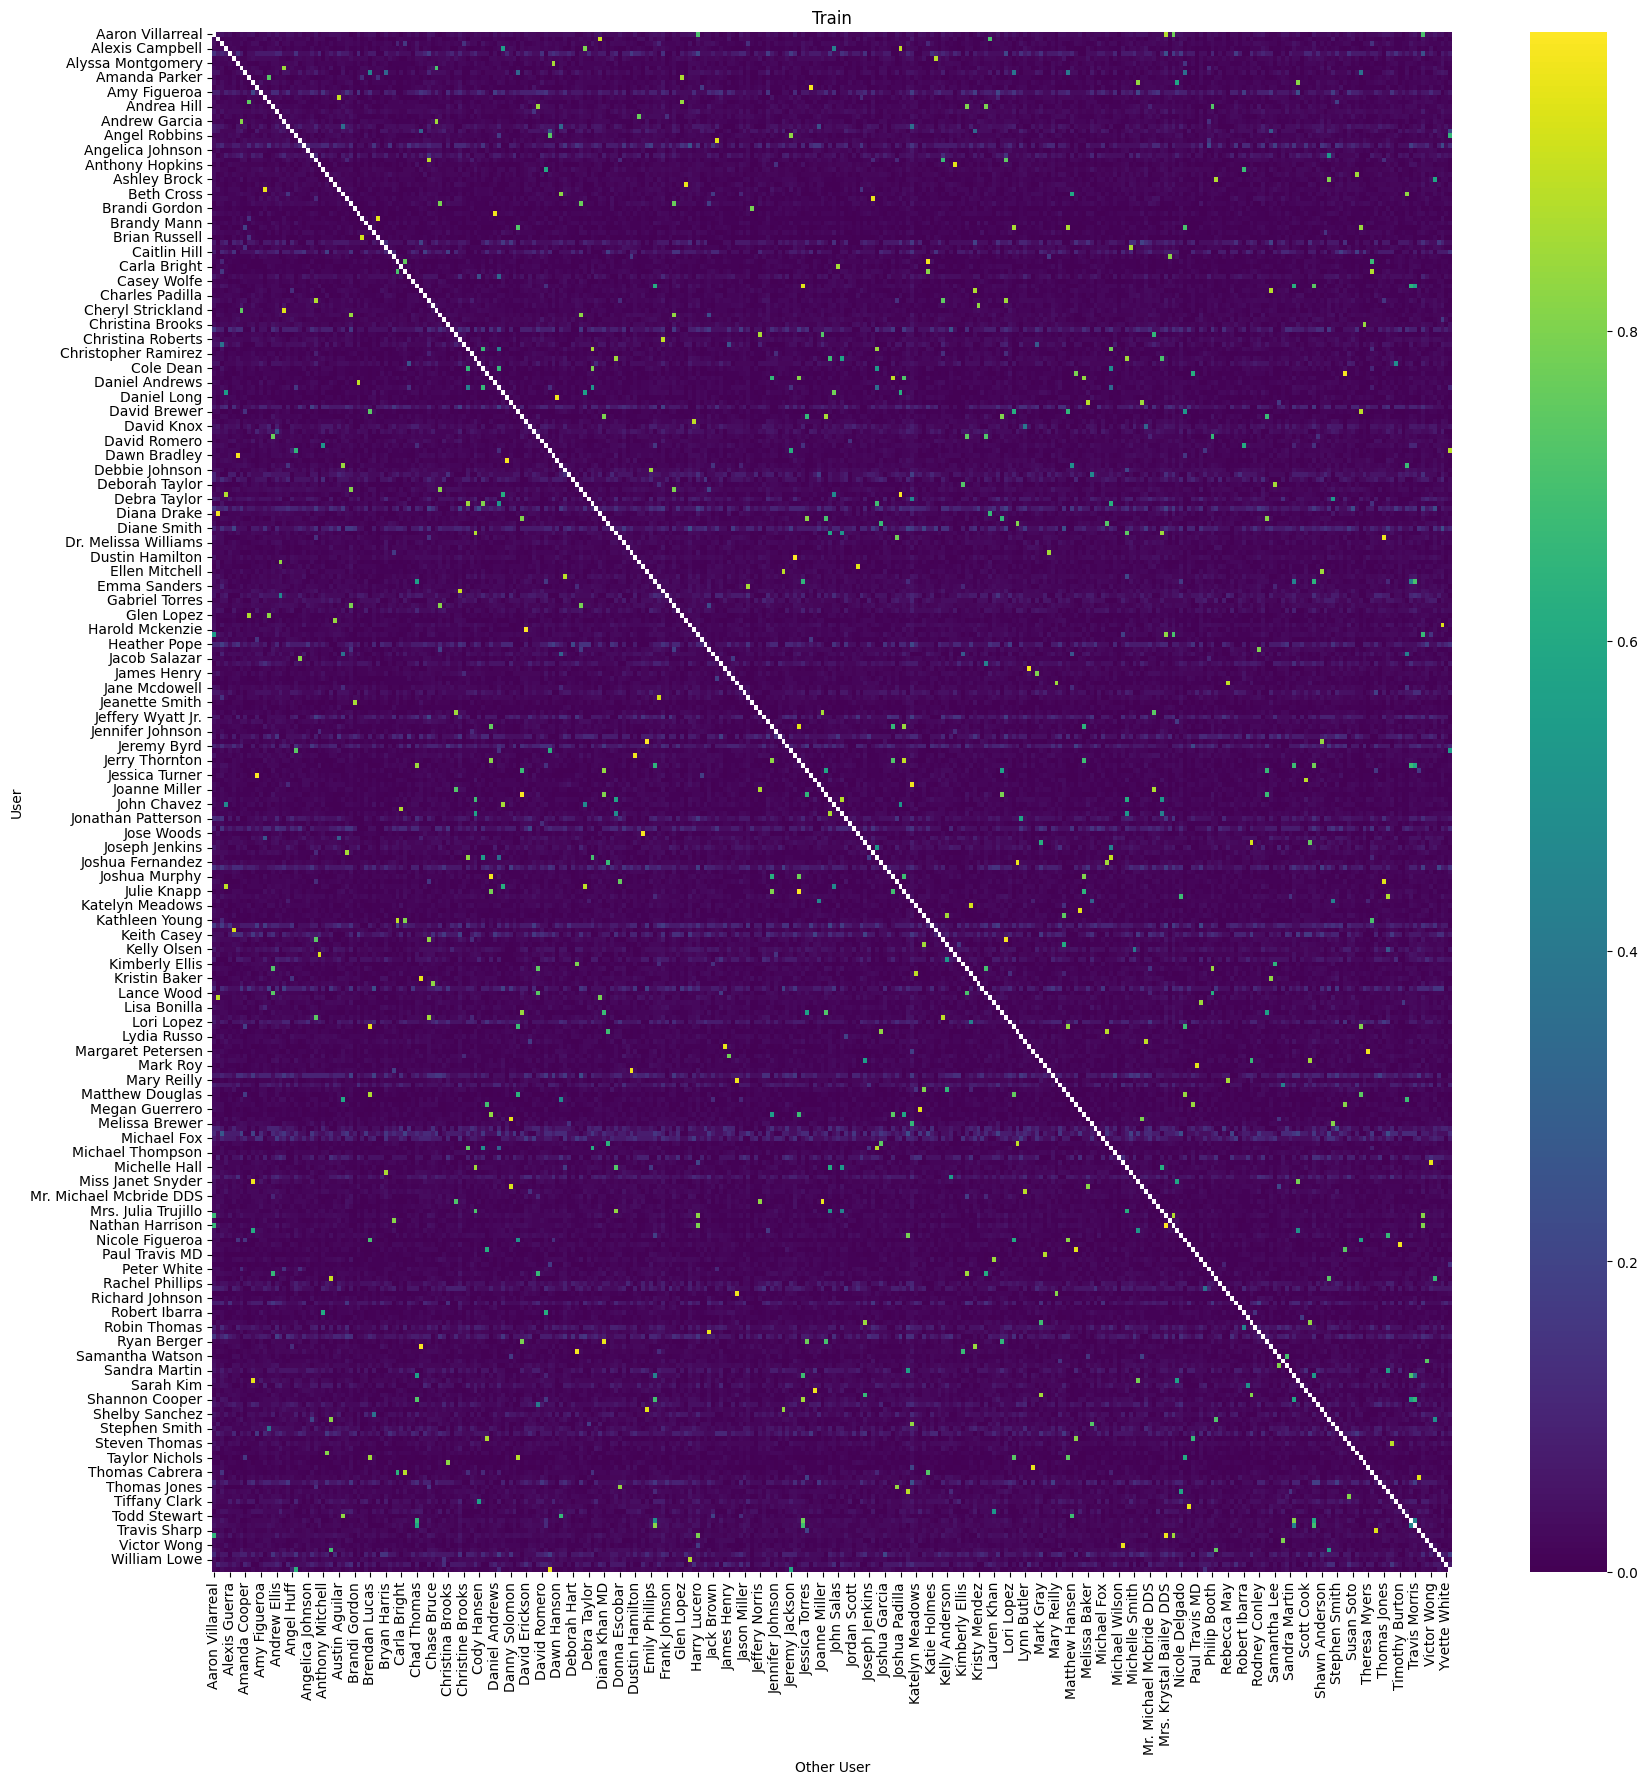

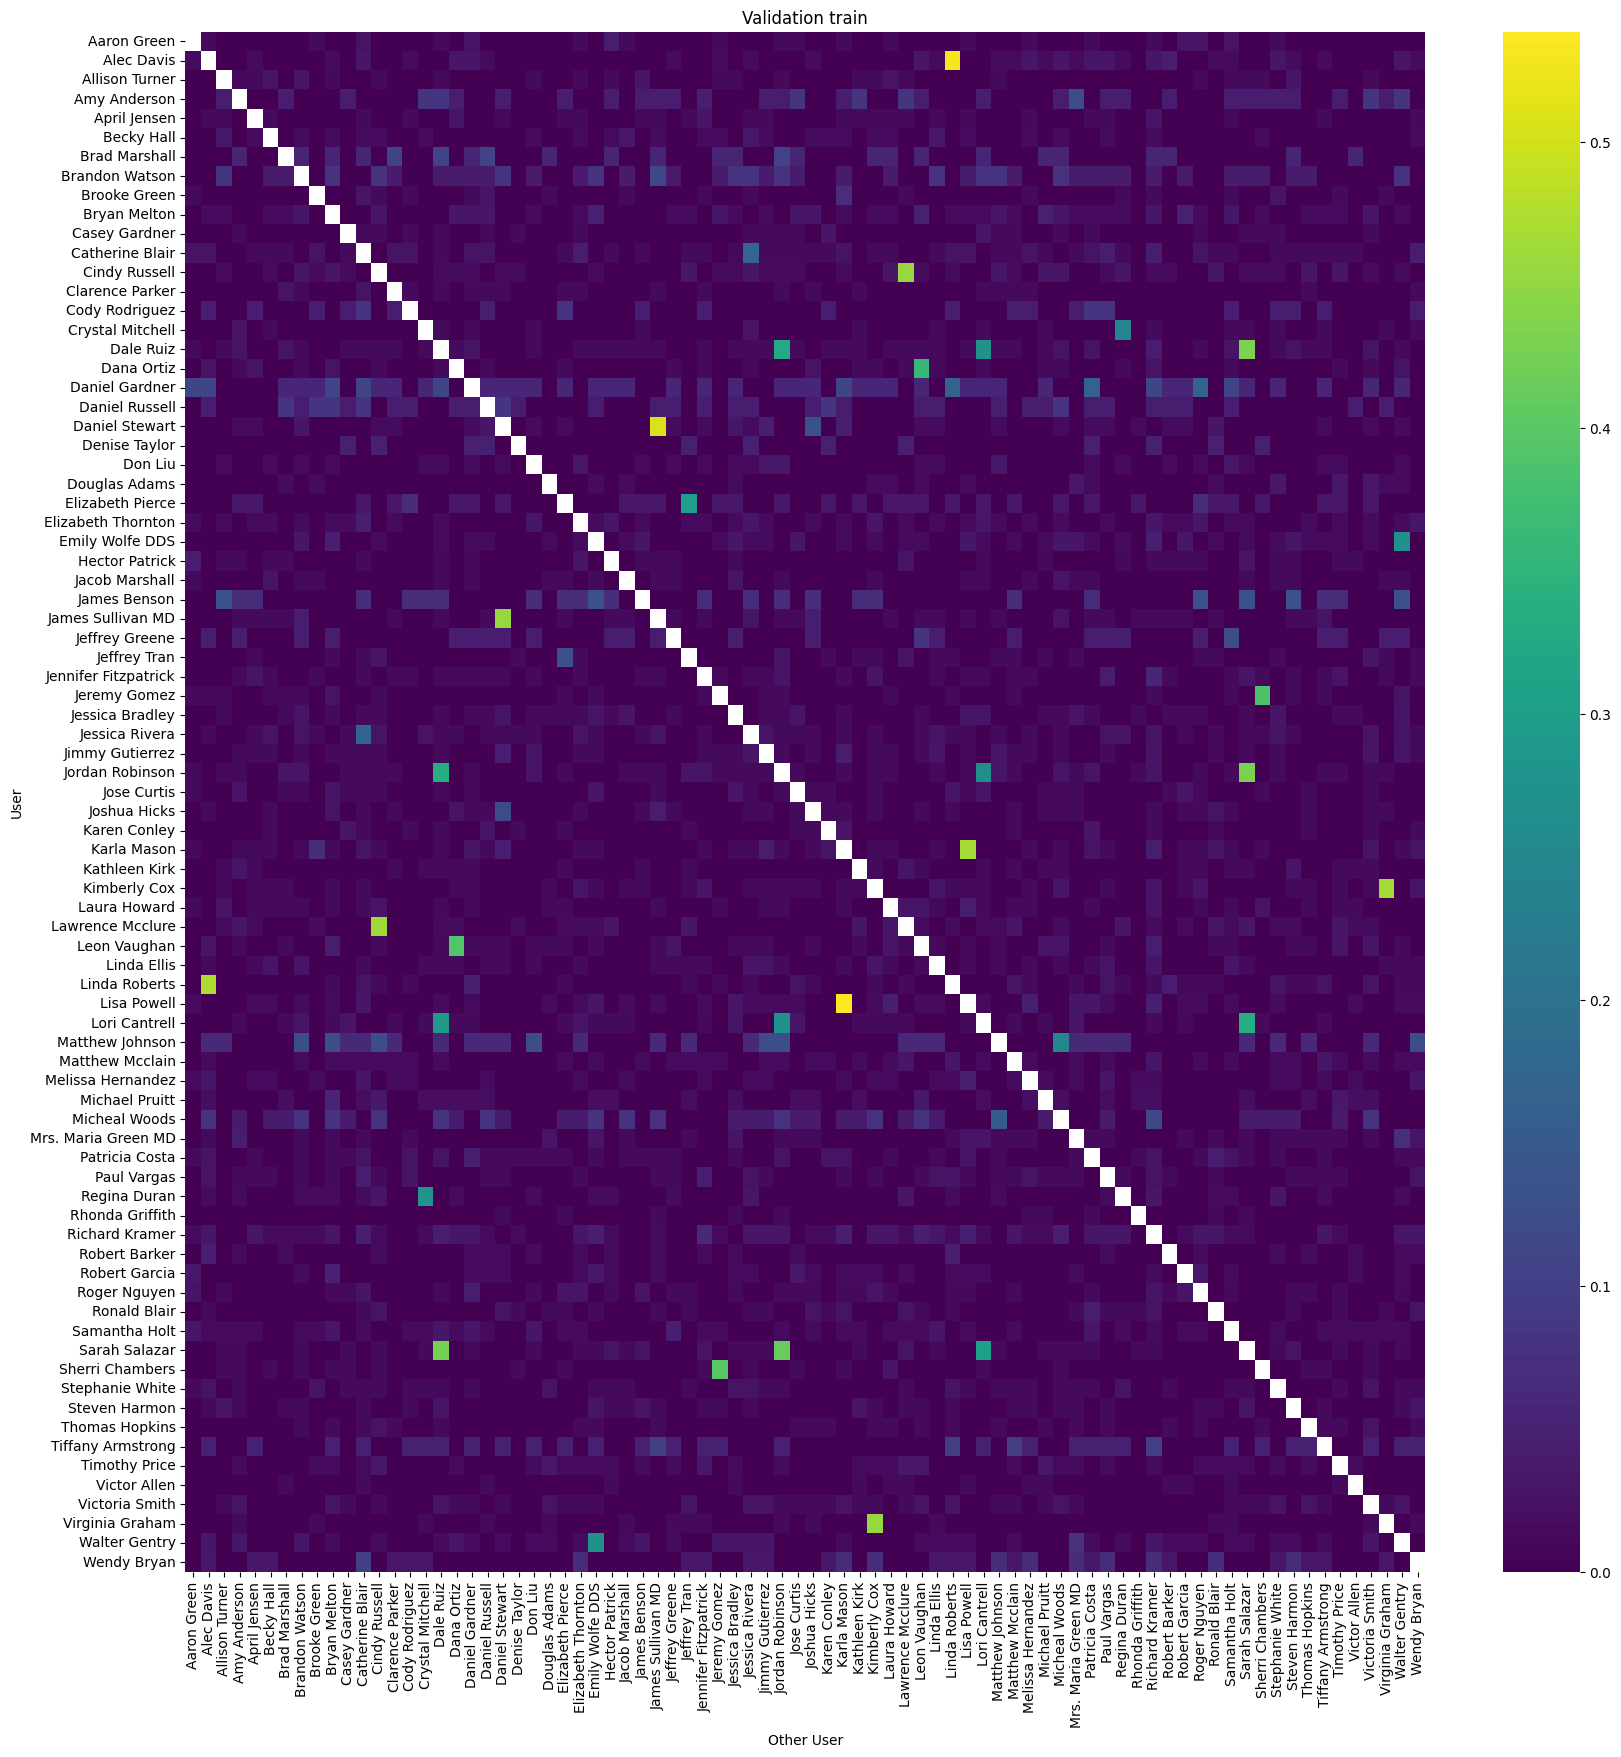

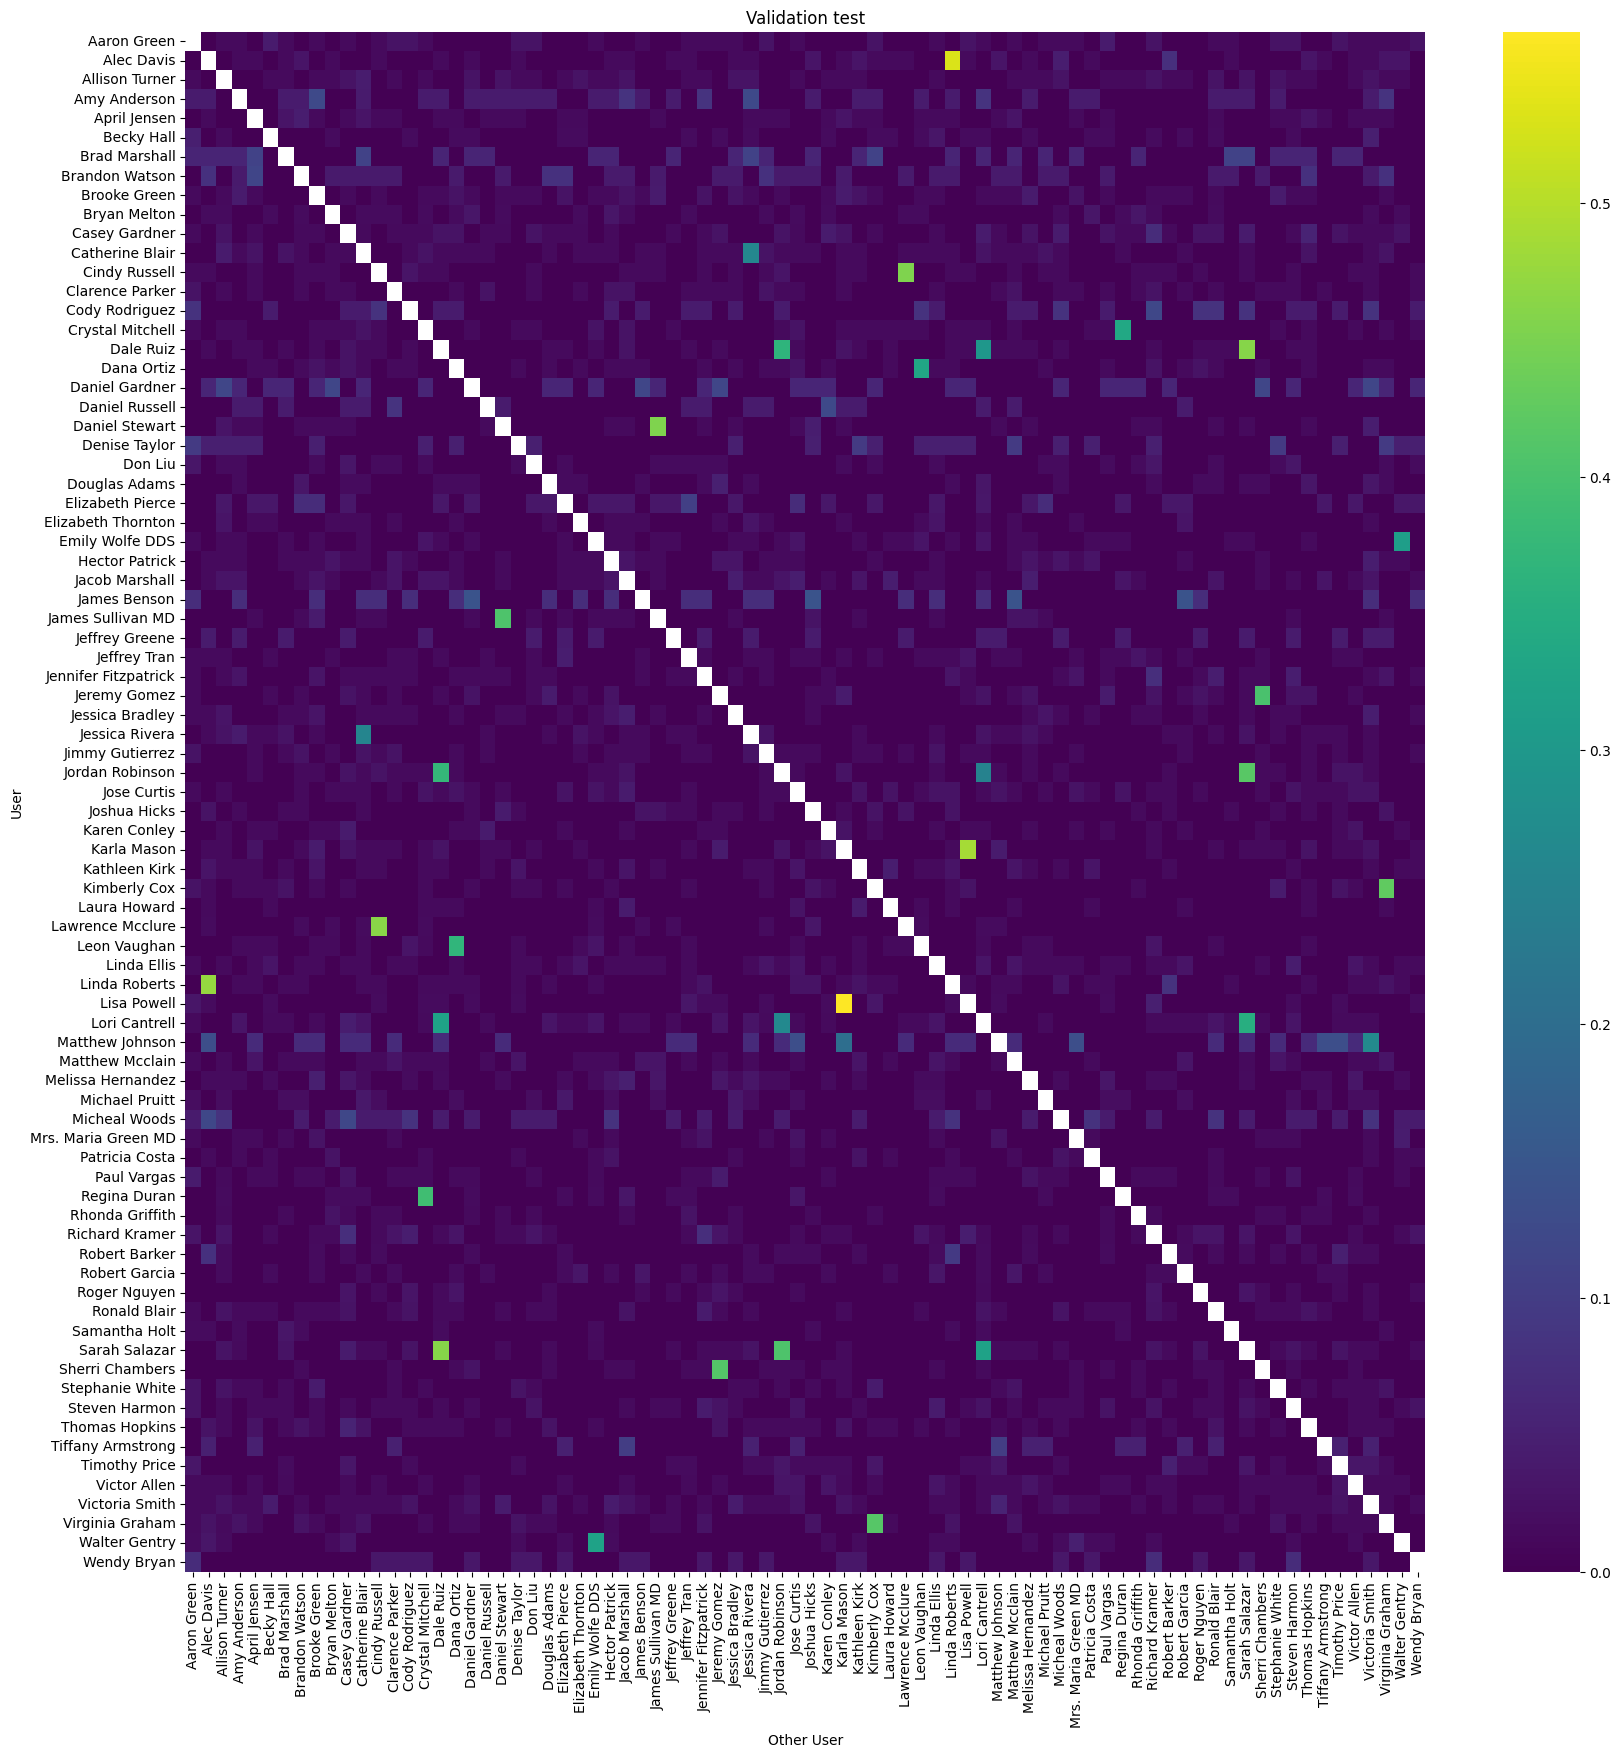

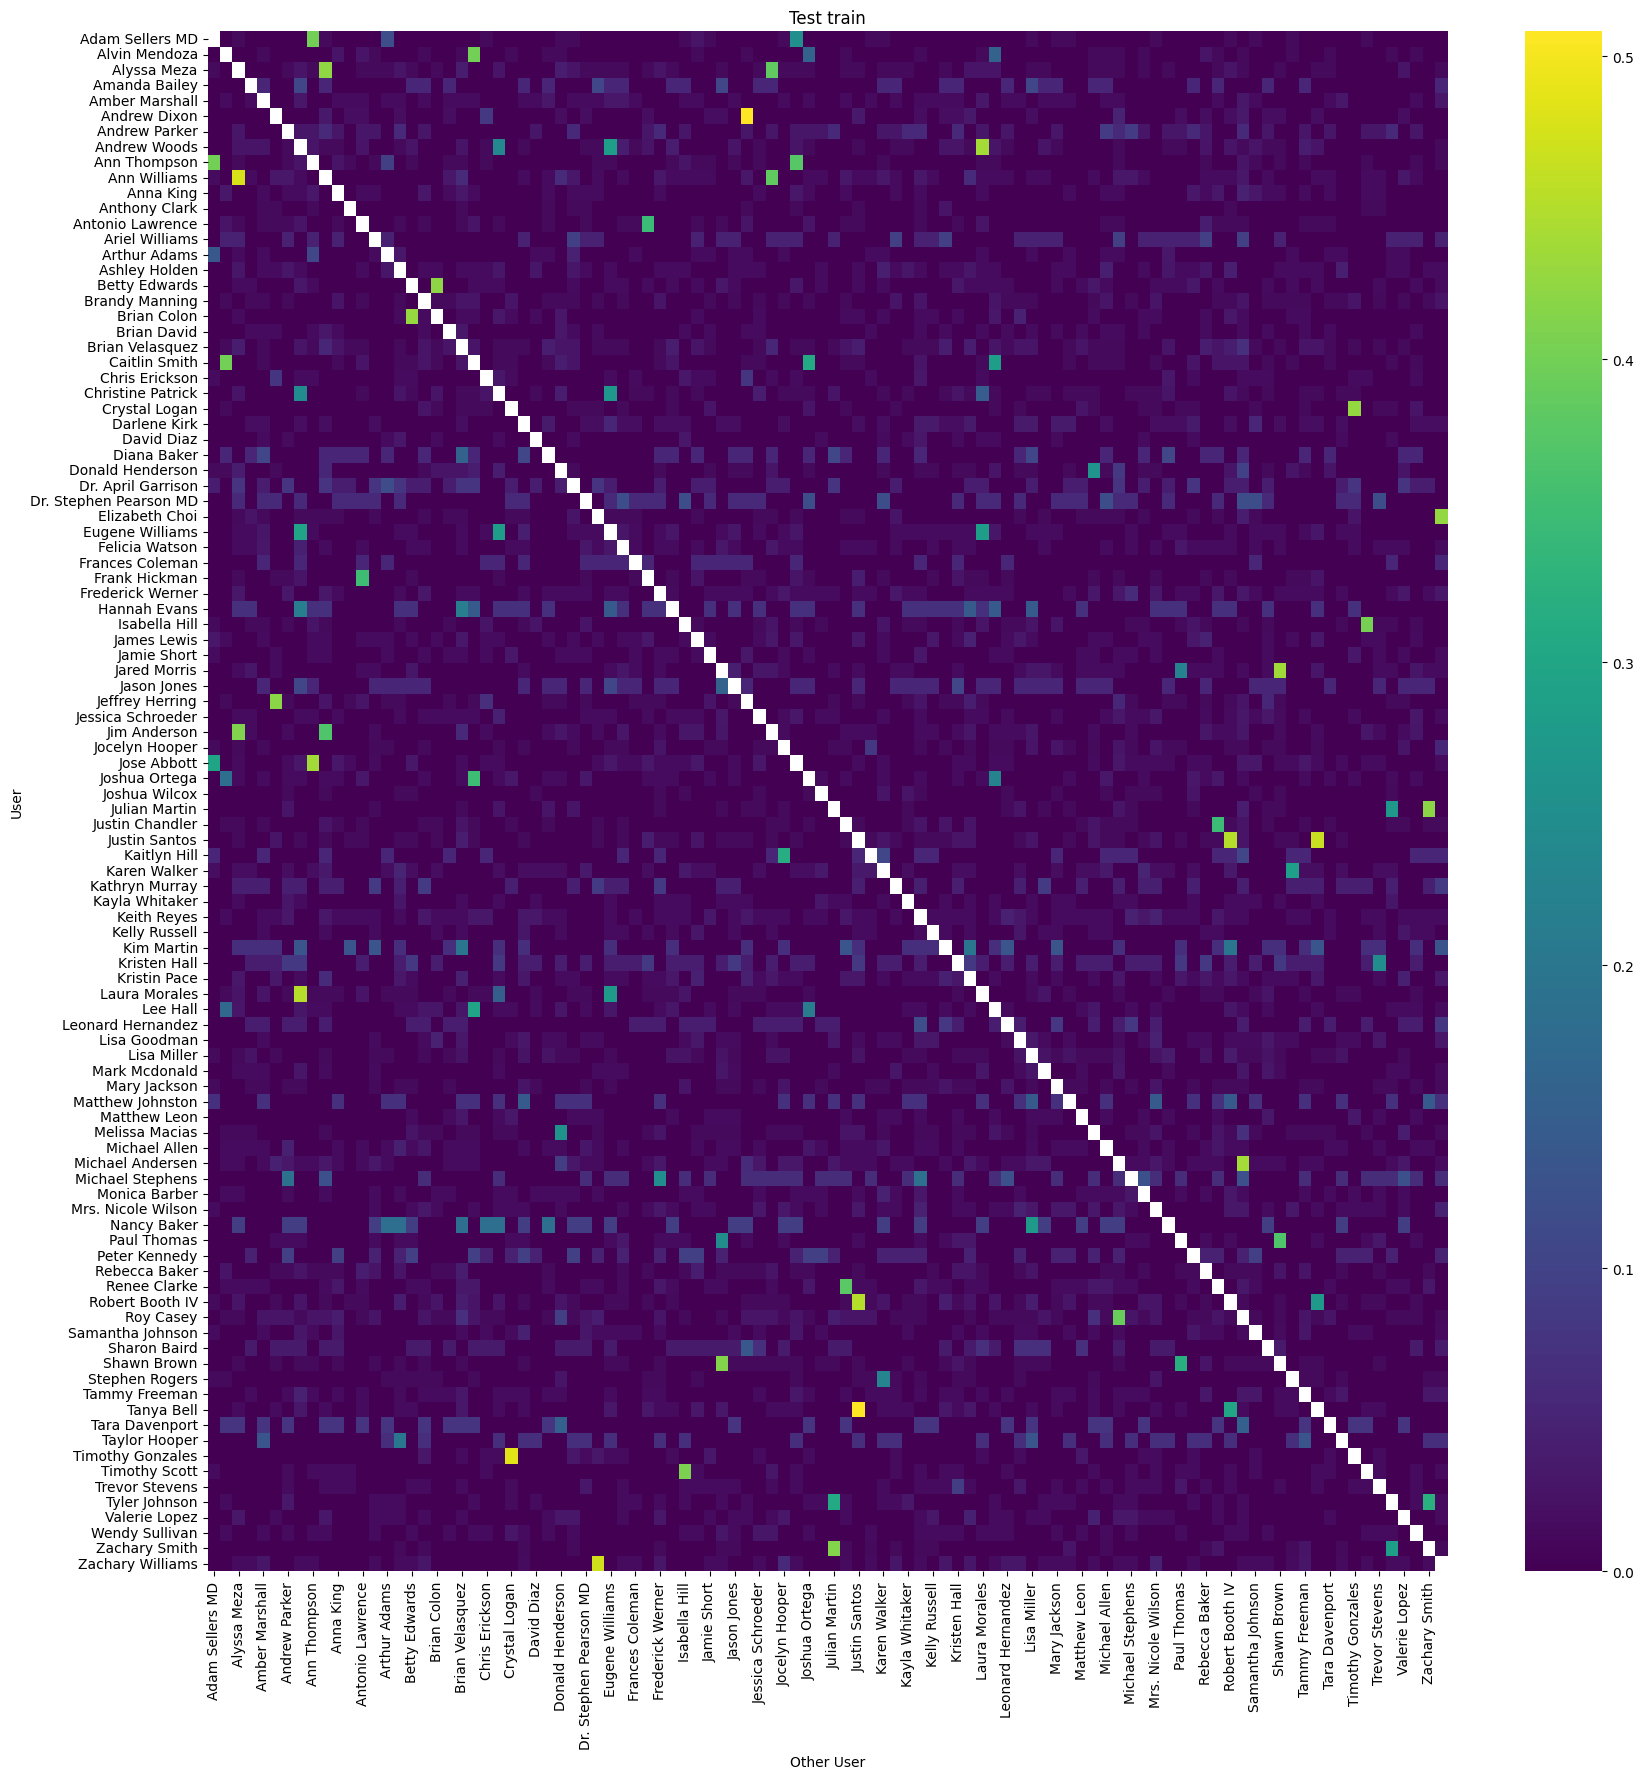

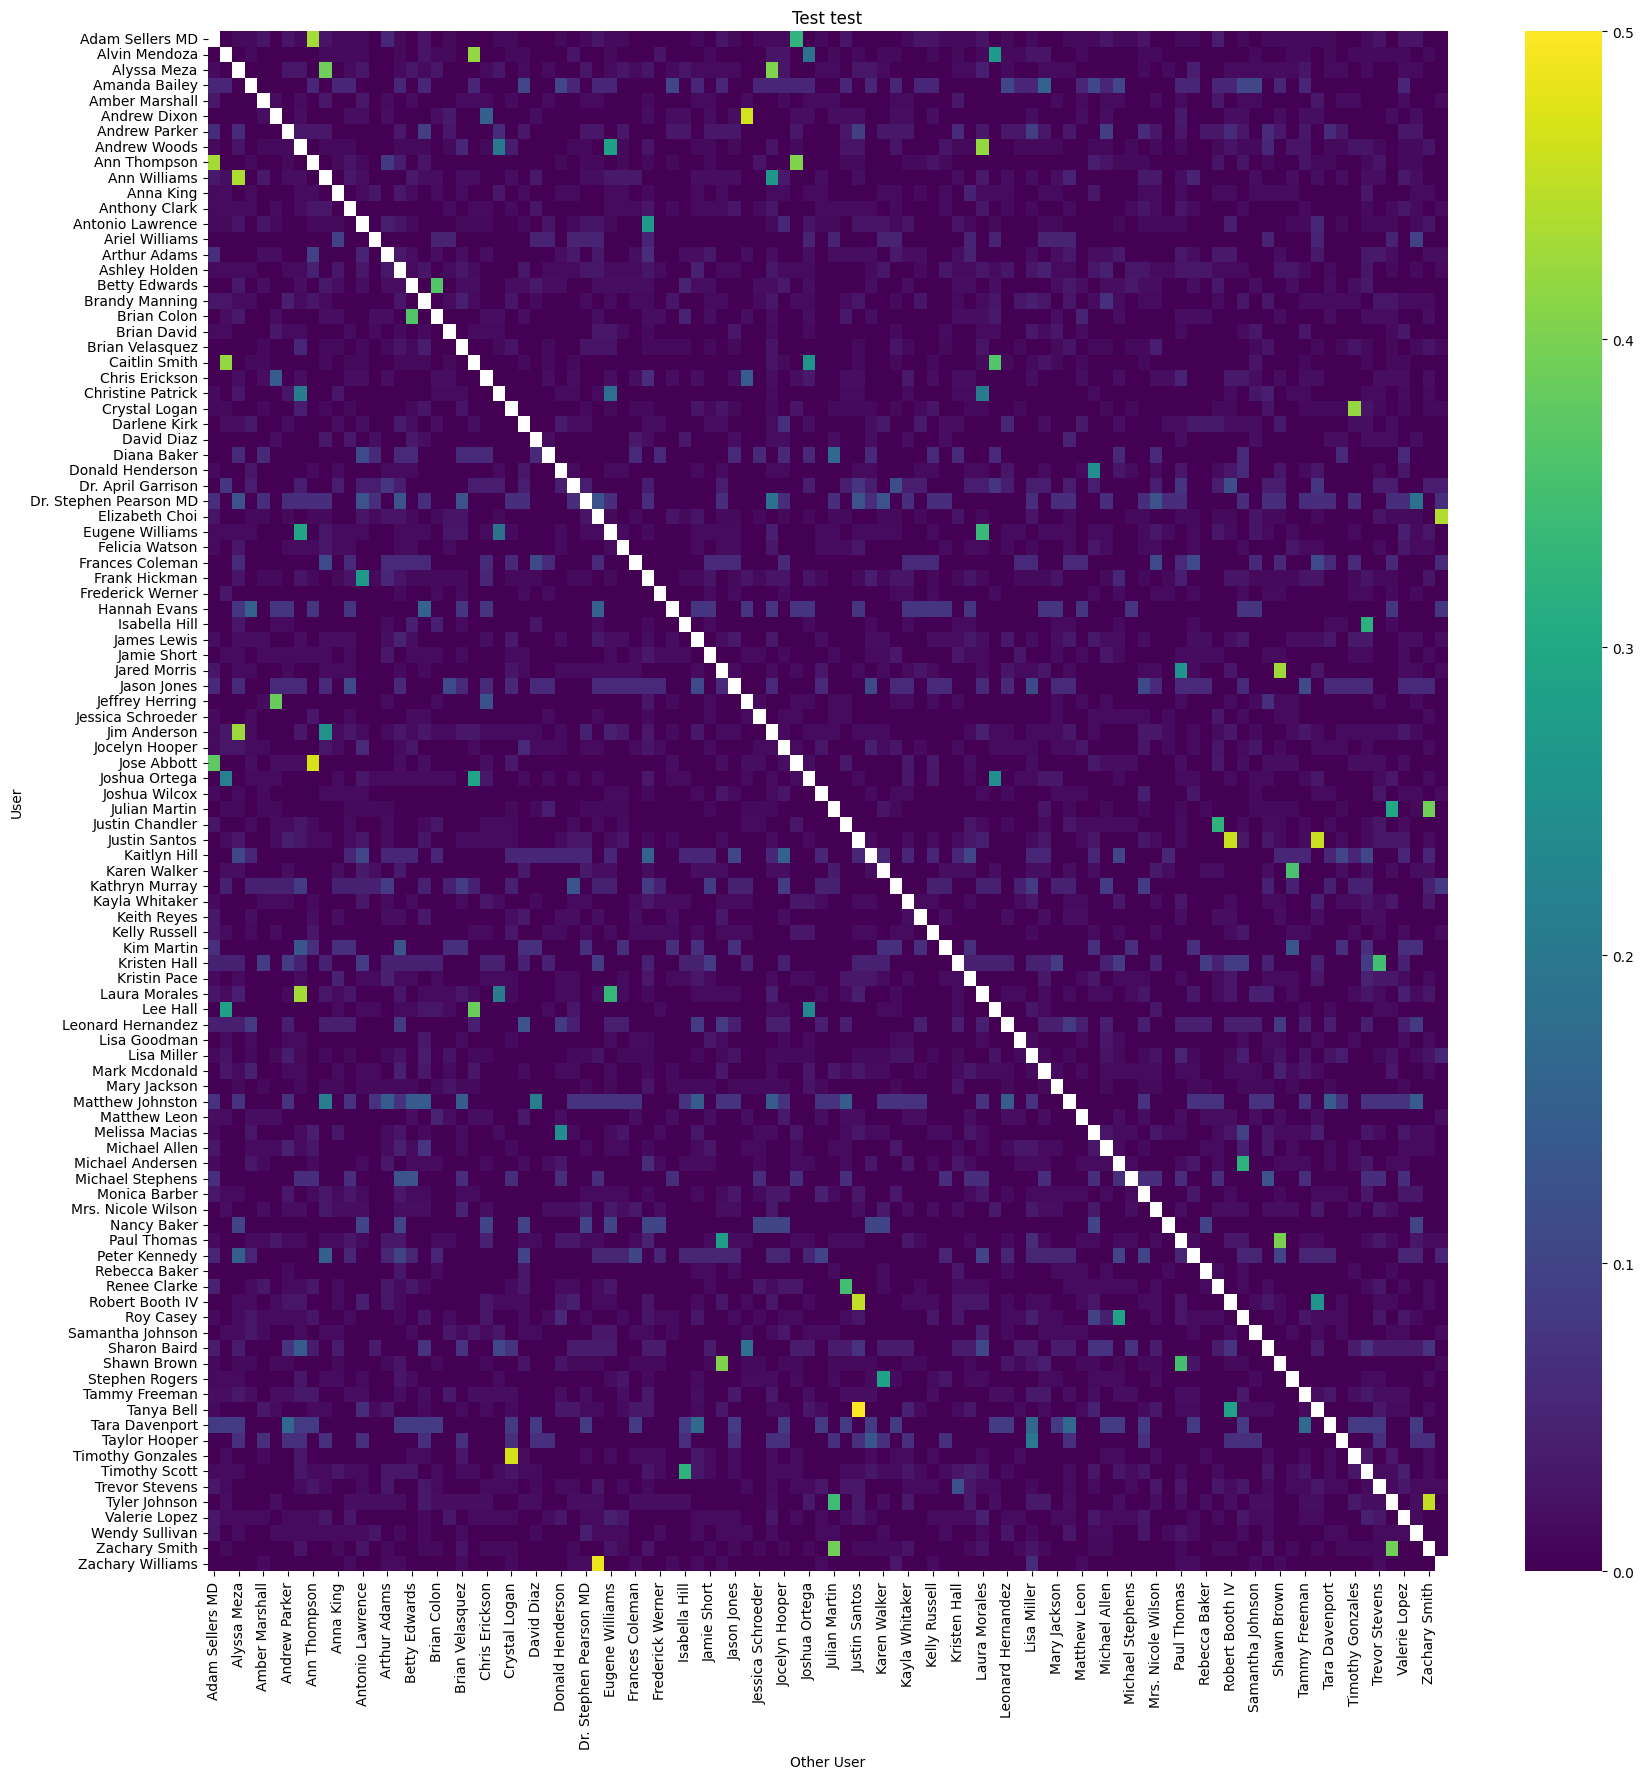

In [11]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)

In [12]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([498, 15549])
Train dataset shape: torch.Size([318, 15549])
Validation train dataset shape: torch.Size([80, 15549])
Validation test dataset shape: torch.Size([80, 15549])
Test train dataset shape: torch.Size([100, 15549])
Test test dataset shape: torch.Size([100, 15549])


In [13]:
whole_matrix_dataset.R

tensor([[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ..., 108.8077,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000]],
       device='mps:0')

In [14]:
train_dataset = TensorDataset(train_matrix_dataset.R)
validation_dataset = TensorDataset(validation_train_matrix_dataset.R, validation_test_matrix_dataset.R)
test_dataset = TensorDataset(test_train_matrix_dataset.R, test_test_matrix_dataset.R)

# Define and train the MultiVAE model

In [15]:
p_dims = [200, 600, whole_matrix_dataset.R.shape[1]]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)
model

MultiVAE(
  (q_layers): ModuleList(
    (0): Linear(in_features=15549, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=400, bias=True)
  )
  (p_layers): ModuleList(
    (0): Linear(in_features=200, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=15549, bias=True)
  )
  (drop): Dropout(p=0.5, inplace=False)
)

In [16]:
batch_size = 32
anneal_cap = 0.2
total_anneal_steps = 200000

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
best_model, loss_history, validation_loss_history, ndcg_history, r20_history, r50_history = model.train_model(
    optimizer,
    train_loader,
    num_epochs=30,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    validation_dataloader=validation_loader,
    log_interval=1,
)

Epoch: 0 	 Loss: 148825.875000 	 Val Loss: 77433.625000 	 NDCG_100: 9.972821 	 Recall_20: 0.080278 	 Recall_50: 0.064945
Epoch: 1 	 Loss: 147724.500000 	 Val Loss: 77071.359375 	 NDCG_100: 9.872880 	 Recall_20: 0.064236 	 Recall_50: 0.066083
Epoch: 2 	 Loss: 143402.843750 	 Val Loss: 78002.640625 	 NDCG_100: 11.126927 	 Recall_20: 0.080180 	 Recall_50: 0.072379
Epoch: 3 	 Loss: 139476.765625 	 Val Loss: 77251.304688 	 NDCG_100: 14.519867 	 Recall_20: 0.109406 	 Recall_50: 0.096550
Epoch: 4 	 Loss: 134525.281250 	 Val Loss: 75078.187500 	 NDCG_100: 17.829573 	 Recall_20: 0.143235 	 Recall_50: 0.119420
Epoch: 5 	 Loss: 126884.578125 	 Val Loss: 72444.945312 	 NDCG_100: 23.766140 	 Recall_20: 0.184753 	 Recall_50: 0.162570
Epoch: 6 	 Loss: 117330.898438 	 Val Loss: 68703.062500 	 NDCG_100: 33.469215 	 Recall_20: 0.249902 	 Recall_50: 0.234725
Epoch: 7 	 Loss: 107797.570312 	 Val Loss: 65444.851562 	 NDCG_100: 47.302818 	 Recall_20: 0.361777 	 Recall_50: 0.348552
Epoch: 8 	 Loss: 100137.13

In [17]:
losses_df = pd.DataFrame([loss_history, validation_loss_history, ndcg_history, r20_history, r50_history]).T
losses_df.columns = ["loss", "validation_loss", "ndgk", "r20", "r50"]

px.line(losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss").show()
px.line(losses_df, x=losses_df.index, y=["ndgk", "r20", "r50"], title="Metrics").show()

In [18]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
total_loss, ndcg, recall_20, recall_50 = best_model.evaluate_model(
    test_loader,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
)
print(f"Total loss: {total_loss}")
print(f"NDCG_100: {ndcg}")
print(f"Recall_20: {recall_20}")
print(f"Recall_50: {recall_50}")

Total loss: 57479.18986328125
NDCG_100: 75.8438491821289
Recall_20: 0.4980352818965912
Recall_50: 0.5175721645355225


In [19]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf["username"].sort_values().unique().tolist()
user_names

['Aaron Green',
 'Aaron Villarreal',
 'Adam Sellers MD',
 'Alec Davis',
 'Alexa Tran',
 'Alexander Bishop',
 'Alexis Campbell',
 'Alexis Guerra',
 'Allison Green',
 'Allison Turner',
 'Alvin Mendoza',
 'Alyssa Meza',
 'Alyssa Montgomery',
 'Amanda Bailey',
 'Amanda Castaneda',
 'Amanda Cooper',
 'Amanda Parker',
 'Amanda Perry',
 'Amber Marshall',
 'Amber Pena',
 'Amy Anderson',
 'Amy Figueroa',
 'Amy Jones',
 'Ana Roberts',
 'Andrea Hill',
 'Andrew Dixon',
 'Andrew Ellis',
 'Andrew Fisher',
 'Andrew Garcia',
 'Andrew Parker',
 'Andrew Wood',
 'Andrew Woods',
 'Angel Huff',
 'Angel Robbins',
 'Angela Nguyen',
 'Angela Williams',
 'Angelica Johnson',
 'Ann Thompson',
 'Ann Williams',
 'Anna King',
 'Anna Stevenson',
 'Anne Pierce',
 'Anthony Clark',
 'Anthony Hopkins',
 'Anthony Mitchell',
 'Anthony Robinson',
 'Antonio Lawrence',
 'April Jensen',
 'Ariel Williams',
 'Arthur Adams',
 'Ashley Brock',
 'Ashley Holden',
 'Ashley Mcgee',
 'Austin Aguilar',
 'Becky Hall',
 'Beth Cross',
 'Be

In [20]:
z, mu, std, logvar = best_model.get_latent_representations(whole_matrix_dataset.R)

print(z.shape)
print(mu.shape)
print(std.shape)
print(logvar.shape)

torch.Size([498, 200])
torch.Size([498, 200])
torch.Size([498, 200])
torch.Size([498, 200])


In [21]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(10, 15)
dim2 = range(10, 15)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

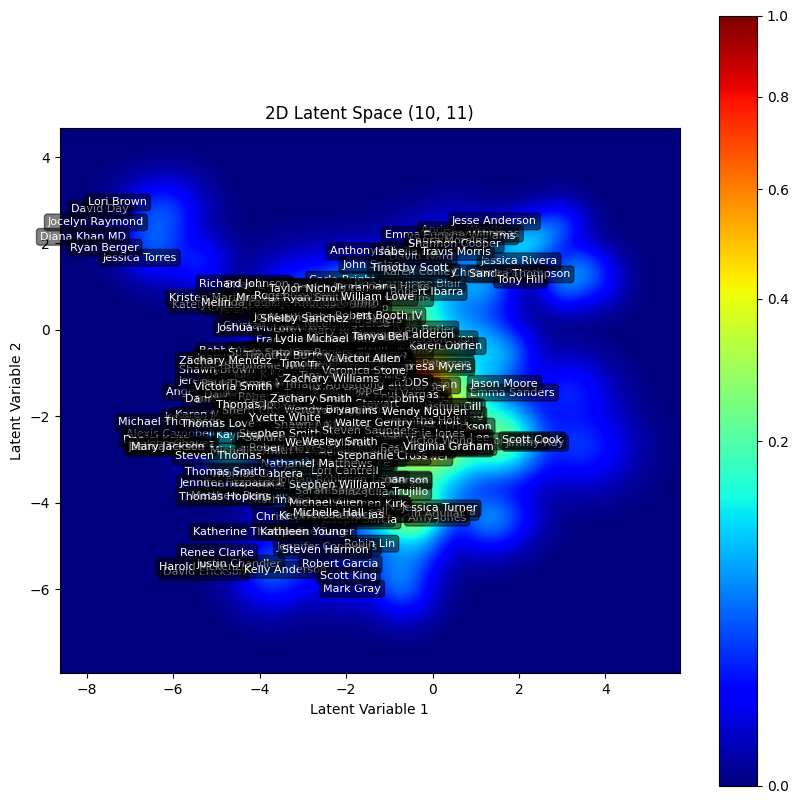

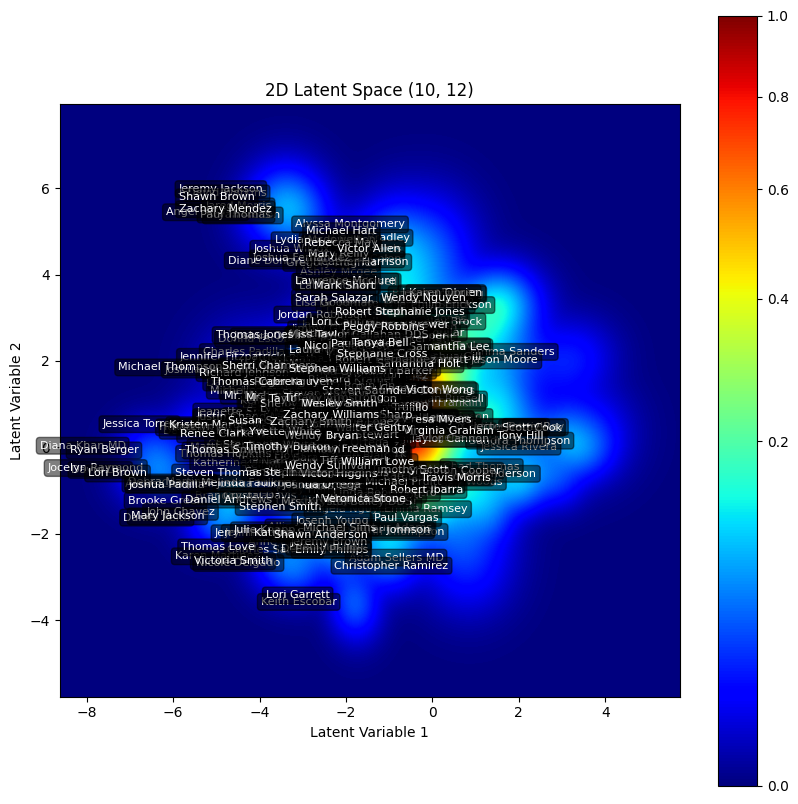

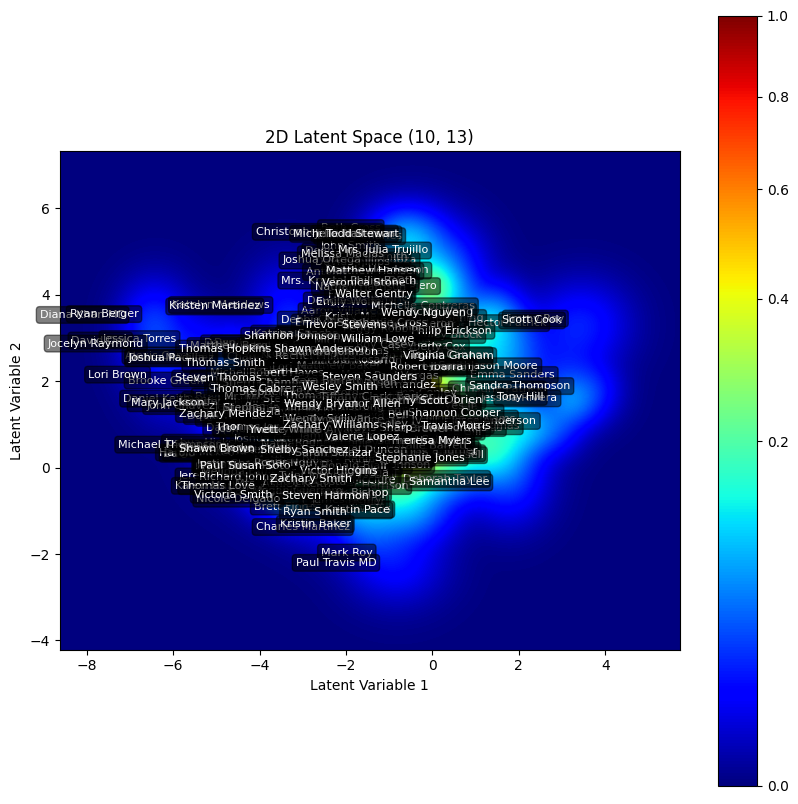

In [22]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plotting.plot_multivariate_gaussian_image_with_labels(
            mu.cpu().numpy()[:, [i, j]],
            std.cpu().numpy()[:, [i, j]],
            color_map="jet",
            # dpi=300,
            labels=user_names,
            title=f"2D Latent Space ({i}, {j})",
        )

In [ ]:
username = "owen"
user_id = whole_matrix_dataset.usernames_to_ids([username])[0]
username = whole_matrix_dataset.ids_to_usernames([user_id])[0]
print(f"User id: {user_id}, {username}")
user_seen = whole_matrix_dataset.get_interactions_ids(user_id)
user_seen.cpu().numpy().shape

User id: 6, owen


(274,)

In [ ]:
user_seen.cpu().numpy()

array([  0,   2,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  15,
        16,  18,  22,  24,  26,  28,  29,  32,  33,  34,  35,  38,  39,
        40,  41,  42,  44,  48,  51,  52,  53,  54,  56,  57,  58,  60,
        63,  65,  67,  69,  70,  71,  72,  74,  75,  77,  78,  79,  80,
        81,  82,  83,  85,  87,  88,  90,  91,  92,  93,  95,  96,  97,
        98,  99, 101, 102, 104, 108, 109, 111, 112, 114, 115, 116, 117,
       118, 124, 125, 126, 127, 132, 133, 135, 136, 139, 140, 143, 144,
       147, 150, 151, 152, 158, 159, 163, 164, 165, 167, 170, 171, 174,
       175, 176, 180, 182, 184, 186, 187, 188, 189, 191, 192, 196, 197,
       198, 199, 200, 202, 204, 205, 207, 208, 210, 212, 214, 215, 216,
       217, 218, 220, 222, 224, 225, 226, 227, 228, 229, 230, 234, 235,
       237, 239, 240, 241, 243, 244, 245, 247, 248, 249, 251, 254, 255,
       256, 258, 259, 260, 261, 265, 266, 267, 268, 269, 272, 273, 276,
       277, 278, 280, 281, 282, 284, 285, 289, 290, 291, 292, 29

In [ ]:
similar_users_ids = best_model.sort_similar_users(user_id=user_id, latent_representations=z)
most_similar_users = whole_matrix_dataset.ids_to_usernames(similar_users_ids.cpu().numpy())[1:]
most_similar_users

['jaslkh', 'paul', 'brenda', 'lsirwguhu', 'michelle', 'dany', 'arthur']

In [ ]:
items_ids, predicted_scores = best_model.recommend(matrix=whole_matrix_dataset.R)
recommendation_df: pd.DataFrame = whole_matrix_dataset.df.copy()
recommendation_df["item_id"] = recommendation_df["id"].cat.codes.astype("int")
recommendation_df.set_index("item_id", inplace=True)

# Get df in the same order as the ids
recommendation_df = recommendation_df.loc[items_ids.cpu().numpy()[user_id]]
recommendation_df["predicted_scores"] = pd.Series(predicted_scores.cpu().numpy()[user_id], index=items_ids.cpu().numpy()[user_id])

recommendation_df = recommendation_df[recommendation_df["username"] != username]
recommendation_df = recommendation_df.drop_duplicates(subset=["username", "id"])
recommendation_df["seen"] = recommendation_df.index.isin(user_seen.cpu().numpy())
# recommendation_df = recommendation_df[recommendation_df["seen"] == False]
recommendation_df = recommendation_df.sort_values(by="predicted_scores", ascending=False)

columns = spoti.PRETTY_PRINT_FEATURES
# columns = list(recommendation_df.columns)
recommendation_df[["id", "predicted_scores", "seen"] + columns].head(50)

,id,predicted_scores,seen,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
item_id,,,,,,,,,,,,,,,,,,,,
336,6Dt6avd8V0rBotNLj9yMy3,2.858766,True,jaslkh,Iliona,Si tu m'aimes demain,2022,59,0.854,0.501,0.0310,0.632000,0.001190,0.1030,0.4650,105.011,-9.535,176026,2022,59
336,6Dt6avd8V0rBotNLj9yMy3,2.858766,True,dany,Iliona,Si tu m'aimes demain,2022,59,0.854,0.501,0.0310,0.632000,0.001190,0.1030,0.4650,105.011,-9.535,176026,2022,59
331,67bPDXCsUNsxyNnNg3jYGO,2.526775,True,dany,Nekfeu,Alunissons,2019,55,0.370,0.328,0.0488,0.821000,0.000433,0.1990,0.2320,134.549,-11.580,278333,2019,55
152,2WbO03LqBgClR6Cba85lJb,2.318843,True,dany,Iliona,Tête brûlée,2022,34,0.525,0.382,0.0713,0.807000,0.025700,0.1080,0.1760,179.956,-12.588,285940,2022,34
340,6H4X9KDDdukPaS8WPJiYDV,2.117334,True,dany,Nekfeu,De mes cendres,2019,54,0.747,0.500,0.0671,0.628000,0.000513,0.1430,0.5420,140.414,-8.346,216226,2019,54
63,0s5gtv1tHwd89TdRYpzfDd,2.097843,True,dany,Feu! Chatterton,Monde Nouveau,2021,53,0.673,0.497,0.0293,0.085400,0.003590,0.1690,0.1160,107.037,-9.357,214464,2021,53
308,5iMiNstvttyZASTAHs19lW,2.062300,True,dany,Iliona,micha,2022,49,0.795,0.417,0.0364,0.679000,0.573000,0.1090,0.4460,121.989,-12.028,233413,2022,49
359,6XXXWiYJTPPVHxHewxGeY5,2.025748,True,jaslkh,Iliona,Garçon manqué,2022,45,0.822,0.399,0.0381,0.693000,0.101000,0.1030,0.3990,119.981,-9.382,211386,2022,45
359,6XXXWiYJTPPVHxHewxGeY5,2.025748,True,dany,Iliona,Garçon manqué,2022,45,0.822,0.399,0.0381,0.693000,0.101000,0.1030,0.3990,119.981,-9.382,211386,2022,45
